In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

## 1. PINN Architecture Definition (Hard Model)
Definition of the standard Neural Network (Multi-Layer Perceptron) and the `SolutionHard` wrapper class that analytically enforces the boundary and initial conditions by construction ($U = A + B \cdot N$).

In [2]:
class PinnHeatEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        return self.couche_sortie(x)

## 2. Collocation Points Generation
Functions to generate collocation points in the domain (since boundary and initial conditions are satisfied analytically by construction).

In [3]:
t_min, t_max = 0.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    t_colloc = torch.rand(n_pde, 1) * (t_max - t_min) + t_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return t_colloc.float(), x_colloc.float()

## 3. Loss Function Definition (Hard Formulation)
Definition of the PDE residual loss function (CLP) for collocation points.

In [4]:
""" Dans un PINN HARD , uniquement la CLP LOSS est necessaire  et on definit A et B tq U = A + B * N 
satisfait toutes les conditions"""

def A(t, x):
    return torch.sin(2 * torch.pi * x)


def B(t, x):
    return t * x * (1 - x)


class SolutionHard(nn.Module):
    def __init__(self, reseau):
        super().__init__()
        self.reseau = reseau

    def forward(self, entrees):
        t, x = entrees[:, :1], entrees[:, 1:]
        return A(t, x) + B(t, x) * self.reseau(entrees)


def calc_clp_loss(model, t_colloc, x_colloc, alpha):
 #   lambda_reg = 0.00000001
    t_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    u_pred = model(torch.cat([t_colloc, x_colloc], dim=1))

    u_t = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_x = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]

    u_xxx = torch.autograd.grad(
        outputs=u_xx,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_xx),
        create_graph=True,
    )[0]

    residu = u_t - alpha * u_xx
    #return torch.mean(residu ** 2) + lambda_reg * torch.mean(u_xxx ** 2)
    return torch.mean(residu ** 2) 

## 4. Hardware (Device), Model, and Optimizer Initialization
Hardware detection, model creation, and optimizer definition.

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

alpha = 0.0005

reseau = PinnHeatEq().to(device)
modele = SolutionHard(reseau).to(device)
optimizer = optim.Adam(modele.parameters(), lr=0.001)

t_colloc, x_colloc = generer_points_collocation(12000)
t_colloc, x_colloc = t_colloc.to(device), x_colloc.to(device)

mps


## 5. Model Training
Training phase of the PINN model using the defined optimizers (Adam and/or L-BFGS).

In [6]:
epochs = 12000

for epoch in range(epochs):
    optimizer.zero_grad()

    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, alpha)
    loss_clp.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:05d} | CLP: {loss_clp.item():.2e}")

Epoque 00000 | CLP: 0.000956
Epoque 00100 | CLP: 0.000004
Epoque 00200 | CLP: 0.000003
Epoque 00300 | CLP: 0.000003
Epoque 00400 | CLP: 0.000003
Epoque 00500 | CLP: 0.000003
Epoque 00600 | CLP: 0.000003
Epoque 00700 | CLP: 0.000003
Epoque 00800 | CLP: 0.000003
Epoque 00900 | CLP: 0.000003
Epoque 01000 | CLP: 0.000003
Epoque 01100 | CLP: 0.000003
Epoque 01200 | CLP: 0.000003
Epoque 01300 | CLP: 0.000003
Epoque 01400 | CLP: 0.000003
Epoque 01500 | CLP: 0.000003
Epoque 01600 | CLP: 0.000003
Epoque 01700 | CLP: 0.000003
Epoque 01800 | CLP: 0.000003
Epoque 01900 | CLP: 0.000002
Epoque 02000 | CLP: 0.000001
Epoque 02100 | CLP: 0.000000
Epoque 02200 | CLP: 0.000000
Epoque 02300 | CLP: 0.000000
Epoque 02400 | CLP: 0.000000
Epoque 02500 | CLP: 0.000000
Epoque 02600 | CLP: 0.000000
Epoque 02700 | CLP: 0.000000
Epoque 02800 | CLP: 0.000000
Epoque 02900 | CLP: 0.000000
Epoque 03000 | CLP: 0.000000
Epoque 03100 | CLP: 0.000000
Epoque 03200 | CLP: 0.000000
Epoque 03300 | CLP: 0.000000
Epoque 03400 |

## 6. Visualizing the Results
Comparison of the solution learned by the PINN with the exact analytical solution of the heat equation.

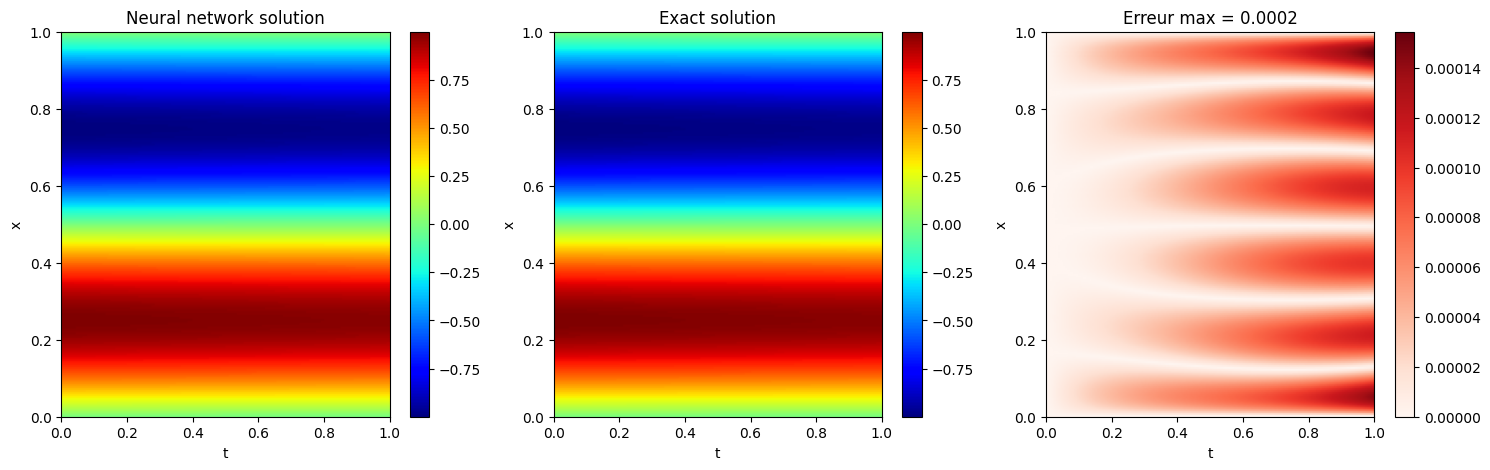

(array([[ 0.0000000e+00,  3.1568550e-02,  6.3105628e-02, ...,
         -6.3105412e-02, -3.1568356e-02,  1.7484555e-07],
        [ 0.0000000e+00,  3.1565193e-02,  6.3098945e-02, ...,
         -6.3098736e-02, -3.1565007e-02,  1.7484555e-07],
        [ 0.0000000e+00,  3.1561837e-02,  6.3092262e-02, ...,
         -6.3092068e-02, -3.1561658e-02,  1.7484555e-07],
        ...,
        [ 0.0000000e+00,  3.0927990e-02,  6.1829180e-02, ...,
         -6.1825417e-02, -3.0925918e-02,  1.7484555e-07],
        [ 0.0000000e+00,  3.0924702e-02,  6.1822630e-02, ...,
         -6.1818864e-02, -3.0922629e-02,  1.7484555e-07],
        [ 0.0000000e+00,  3.0921411e-02,  6.1816078e-02, ...,
         -6.1812311e-02, -3.0919336e-02,  1.7484555e-07]],
       shape=(200, 200), dtype=float32),
 array([[ 0.00000000e+00,  3.15685498e-02,  6.31056313e-02, ...,
         -6.31056313e-02, -3.15685498e-02, -2.44929360e-16],
        [ 0.00000000e+00,  3.15654186e-02,  6.30993720e-02, ...,
         -6.30993720e-02, -3.15654

In [9]:
import sys; sys.path.append("..")
import numpy as np
from pinnplot import plot_solution

u_exact = lambda t, x: np.sin(2*np.pi*x) * np.exp(-(2*np.pi)**2 * alpha * t)

plot_solution(modele, u_exact)